# Import

In [1]:
import sys

sys.path.append(r"D:\Materials\AI\Projects\Lib\torchwires\src")

from torchwires import Repo
from torchwires import BaseCallback
from torchwires import Trainer
from torchwires import Visualizer

In [2]:
import torch
from torch.utils.data import DataLoader, Dataset

import numpy as np

# Create

In [3]:
repo = Repo(
    repo_name="full_test_3",
)

# Models

In [4]:
class LinearStack(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = torch.nn.Linear(10, 10)
        self.activation = torch.nn.ReLU()

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        return x

In [5]:
m1 = LinearStack()

repo.register_model(
    name='m1',
    model=m1
)

Model m1: has been registered
Model m1 weights loaded: path=full_test_3\exp_1\last\m1.weights.pth


# Optimizers

In [6]:
repo.register_optimizer(
    name='m1',
    optimizer= torch.optim.Adam(m1.parameters(), lr=0.001)
)

KeyboardInterrupt: 

# Loaders

In [ ]:
class MyDataset(Dataset):
    def __init__(self):
        self.err = 0.0

    def __len__(self):
        return 30

    def __getitem__(self, index):
        x = torch.rand((10,))
        y = torch.sin(x) + self.err * torch.randn(10) * 0
        return x, y

In [ ]:
train_loader = DataLoader(
        MyDataset(),
        batch_size=2,
)

val_loader = DataLoader(
    MyDataset(),
    batch_size=2,
)

test_loader = DataLoader(
    MyDataset(),
    batch_size=2,
)

# Connections

In [ ]:
repo.add_forward(
    model_name='m1',
    inputs=['x'],
    outputs=['y-hat'],
)

ForwardStep added: y-hat = m1(x)


# Losses & Metrics

In [ ]:
repo.add_loss(
    loss_name='mae',
    loss_function=lambda s: torch.flatten(s['y-hat'] - s['y']).abs().mean(),
    weight_function= lambda s: 1.0
)

LossStep added: mae


In [ ]:
repo.add_metric(
    metric_name='err_inverse',
    metric_function=lambda s: 1 / torch.flatten(s['y-hat'] - s['y']).abs().mean(),
)

MetricStep added: err_inverse


# Callbacks

In [ ]:
trainer = Trainer(
    repo=repo,
    device='cpu'
)

In [ ]:
class CB_1(BaseCallback):
    def on_epoch_start(
            self
    ):
        print("Epoch started.")

    def on_epoch_end(
            self,
            epoch_state,
    ):
        print(f"Epoch {epoch_state.aggregate_over_batches('epoch', 'train', 'mean')} ended.")
        

trainer.register_callback(CB_1())

In [ ]:
trainer.register_checkpoint_callback(
    mode="min",
    monitor="total_loss",
    split="val",
)

In [ ]:
trainer.register_checkpoint_callback(
    mode="max",
    monitor="err_inverse",
    split="val",
)

In [ ]:
trainer.register_auto_save_callback(
    interval=5,
    checkpoint_name="auto_a",
    concat_with_epoch_no=True
)

In [ ]:
trainer.register_auto_save_callback(
    interval=5,
    checkpoint_name="auto_b",
    concat_with_epoch_no=False
)

In [ ]:
trainer.register_early_stopping_callback(
    split='train',
    mode='max',
    monitor='total_loss',
    patience=5
)

# Load

In [ ]:
repo.load()

Model m1 weights loaded: path=full_test_3\exp_1\last\m1.weights.pth
Optimizer m1 loaded: path=full_test_3\exp_1\last\m1.optimizer.pth
History loaded: path=full_test_3\exp_1\history.json
No History Features found: path=full_test_3\exp_1\history_tracked.json


# Training

In [ ]:
trainer.train(
    n_epochs=50,
    train_loader=train_loader,
    val_loader=val_loader,
    loader_output_keys=['x','y']
)

Training full_test_3: Starting training epoch 20 -> 50 epochs
Epoch started.
Epoch: 21/50                                                                                                                                                                                                                                                                                                
train-mae.raw: 0.24088               | val-mae.raw: 0.22966                 | train-mae.weight: 1.00000            | val-mae.weight: 1.00000             
train-mae.eff: 0.24088               | val-mae.eff: 0.22966                 | train-err_inverse: 4.23084           | val-err_inverse: 4.47417            
train-total_loss: 0.24088            | val-total_loss: 0.22966              | train-m1.lr: 0.00100                 | val-m1.lr: None                     
Epoch 21.0 ended.
Checkpoint taken: val-total_loss improved from inf to 0.229663 | checkpoint name: best_checkpoint_val-total_loss
Model m1 weights saved: path=

Epoch: 22/50                                                                                                                                                                                                                                                                                              
train-mae.raw: 0.23408               | val-mae.raw: 0.23801                 | train-mae.weight: 1.00000            | val-mae.weight: 1.00000             
train-mae.eff: 0.23408               | val-mae.eff: 0.23801                 | train-err_inverse: 4.33324           | val-err_inverse: 4.37323            
train-total_loss: 0.23408            | val-total_loss: 0.23801              | train-m1.lr: 0.00100                 | val-m1.lr: None                     
Epoch 22.0 ended.


Epoch started.
Epoch: 23/50                                                                                                                                                                                                

# Access Models

In [ ]:
repo.get_all_models_names()

['m1']

In [ ]:
repo.get_model_node('m1').get_model()

LinearStack(
  (linear1): Linear(in_features=10, out_features=10, bias=True)
  (activation): ReLU()
)

# Save

In [ ]:
repo.save()

Model m1 weights saved: path=full_test_3\exp_1\last\m1.weights.pth
Optimizer m1 weights saved: path=full_test_3\exp_1\last\m1.optimizer.pth


In [ ]:
repo.save(
    "final_dat"
)

Model m1 weights saved: path=full_test_3\exp_1\final_dat\m1.weights.pth
Optimizer m1 weights saved: path=full_test_3\exp_1\final_dat\m1.optimizer.pth


# Predict

In [ ]:
trainer.predict(
    dataloader=test_loader,
    loader_output_keys=['x','y'],
)

Epoch: 1/1                                                                                                                                                                                                                                                                         
test-mae.raw: 0.23954                | test-mae.weight: 1.00000             | test-mae.eff: 0.23954                | test-err_inverse: 4.24288           
test-total_loss: 0.23954             | test-m1.lr: None                     | 

[{'epoch': 1,
  'batch': 1,
  'loader': 'test',
  'total_loss': tensor(0.2101),
  'x': tensor([[0.3574, 0.5907, 0.7146, 0.8705, 0.1648, 0.4577, 0.2397, 0.2997, 0.6419,
           0.2384],
          [0.6855, 0.3767, 0.4618, 0.1307, 0.8541, 0.9048, 0.2563, 0.3194, 0.1853,
           0.0971]]),
  'y': tensor([[0.3498, 0.5570, 0.6553, 0.7647, 0.1641, 0.4419, 0.2374, 0.2952, 0.5987,
           0.2362],
          [0.6331, 0.3678, 0.4456, 0.1303, 0.7540, 0.7863, 0.2535, 0.3140, 0.1842,
           0.0970]]),
  'y-hat': tensor([0.3622, 0.3765, 0.2350, 0.2256, 0.2259, 0.5109, 0.4716, 0.4287, 0.4250,
          0.3740]),
  'mae.raw': tensor(0.2101),
  'mae.weight': 1.0,
  'mae.eff': tensor(0.2101),
  'err_inverse': tensor(4.7600)},
 {'epoch': 1,
  'batch': 2,
  'loader': 'test',
  'total_loss': tensor(0.2468),
  'x': tensor([[0.2044, 0.2444, 0.8067, 0.2387, 0.3132, 0.3261, 0.9540, 0.3237, 0.7134,
           0.8206],
          [0.1149, 0.6691, 0.0244, 0.2820, 0.7844, 0.2342, 0.9005, 0.0298, 0.3918,

# Visuals

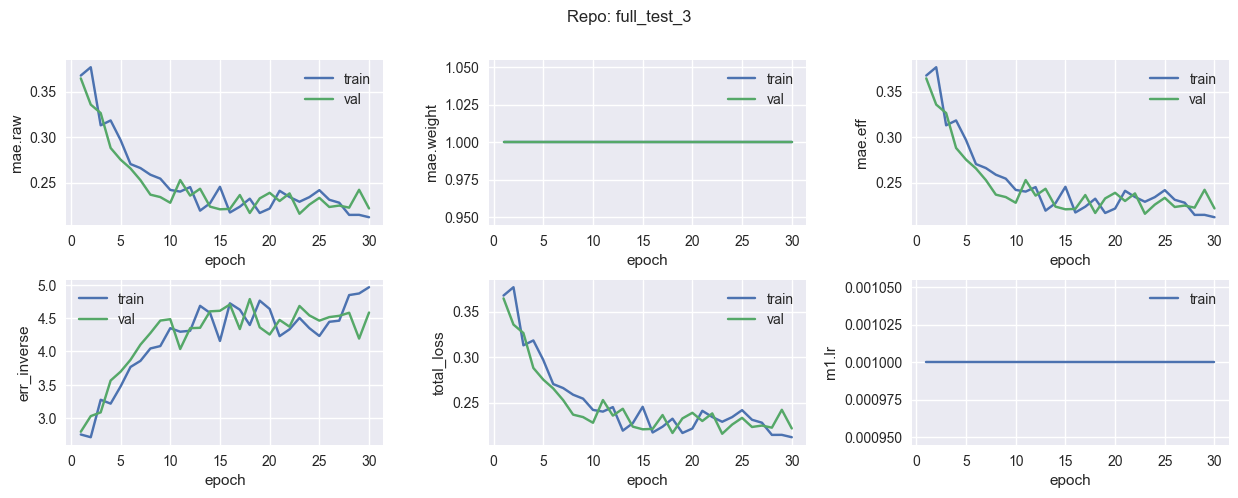

In [ ]:
Visualizer.visualize_repo(
    repo,
      cell_size=(5,2.5),
        style_no=12,
        n_cols=3,
        hspace=1/3,
        wspace=1/3
)

In [ ]:
Visualizer.display_df(repo)

mae.raw  mae.weight   mae.eff  err_inverse  total_loss  m1.lr
epoch loader                                                                
1     train   0.367637         1.0  0.367637     2.751714    0.367637  0.001
      val     0.364511         1.0  0.364511     2.793332    0.364511    NaN
2     train   0.376781         1.0  0.376781     2.710765    0.376781  0.001
      val     0.335683         1.0  0.335683     3.028155    0.335683    NaN
3     train   0.312907         1.0  0.312907     3.273930    0.312907  0.001
      val     0.326393         1.0  0.326393     3.084501    0.326393    NaN
4     train   0.318249         1.0  0.318249     3.216010    0.318249  0.001
      val     0.287987         1.0  0.287987     3.563185    0.287987    NaN
5     train   0.296698         1.0  0.296698     3.473434    0.296698  0.001
      val     0.275153         1.0  0.275153     3.696227    0.275153    NaN
6     train   0.270282         1.0  0.270282     3.767246    0.270282  0.001
      val     0.265442         1.0  0.265442     3.874494    0.265442    NaN
7     train   0.265877         1.0  0.265877     3.858926    0.265877  0.001
      val     0.252614         1.0  0.252614     4.102883    0.252614    NaN
8     train   0.258577         1.0  0.258577     4.045383    0.258577  0.001
      val     0.236645         1.0  0.236645     4.276857    0.236645    NaN
9     train   0.254251         1.0  0.254251     4.081313    0.254251  0.001
      val     0.233981         1.0  0.233981     4.464864    0.233981    NaN
10    train   0.241844         1.0  0.241844     4.350819    0.241844  0.001
      val     0.227714         1.0  0.227714     4.485581    0.227714    NaN
11    train   0.240006         1.0  0.240006     4.297239    0.240006  0.001
      val     0.252711         1.0  0.252711     4.037467    0.252711    NaN
12    train   0.244961         1.0  0.244961     4.311495    0.244961  0.001
      val     0.235587         1.0  0.235587     4.350323    0.235587    NaN
13    train   0.219071         1.0  0.219071     4.686386    0.219071  0.001
      val     0.243133         1.0  0.243133     4.356079    0.243133    NaN
14    train   0.227182         1.0  0.227182     4.580265    0.227182  0.001
      val     0.223464         1.0  0.223464     4.603597    0.223464    NaN
15    train   0.245285         1.0  0.245285     4.157939    0.245285  0.001
      val     0.220541         1.0  0.220541     4.612063    0.220541    NaN
16    train   0.217024         1.0  0.217024     4.724183    0.217024  0.001
      val     0.220983         1.0  0.220983     4.706881    0.220983    NaN
17    train   0.223409         1.0  0.223409     4.628325    0.223409  0.001
      val     0.236236         1.0  0.236236     4.337192    0.236236    NaN
18    train   0.232197         1.0  0.232197     4.398108    0.232197  0.001
      val     0.216491         1.0  0.216491     4.788162    0.216491    NaN
19    train   0.216493         1.0  0.216493     4.764179    0.216493  0.001
      val     0.232517         1.0  0.232517     4.363348    0.232517    NaN
20    train   0.221385         1.0  0.221385     4.639900    0.221385  0.001
      val     0.238687         1.0  0.238687     4.254786    0.238687    NaN
21    train   0.240884         1.0  0.240884     4.230835    0.240884  0.001
      val     0.229663         1.0  0.229663     4.474168    0.229663    NaN
22    train   0.234080         1.0  0.234080     4.333236    0.234080  0.001
      val     0.238013         1.0  0.238013     4.373225    0.238013    NaN
23    train   0.228835         1.0  0.228835     4.504595    0.228835  0.001
      val     0.215626         1.0  0.215626     4.684555    0.215626    NaN
24    train   0.233940         1.0  0.233940     4.350064    0.233940  0.001
      val     0.225736         1.0  0.225736     4.542145    0.225736    NaN
25    train   0.241613         1.0  0.241613     4.233118    0.241613  0.001
      val     0.233137         1.0  0.233137     4.463544    0.233137    NaN
26    train